c:\Users\cwycw\miniconda3\envs\dtu02451\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\cwycw\miniconda3\envs\dtu02451\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


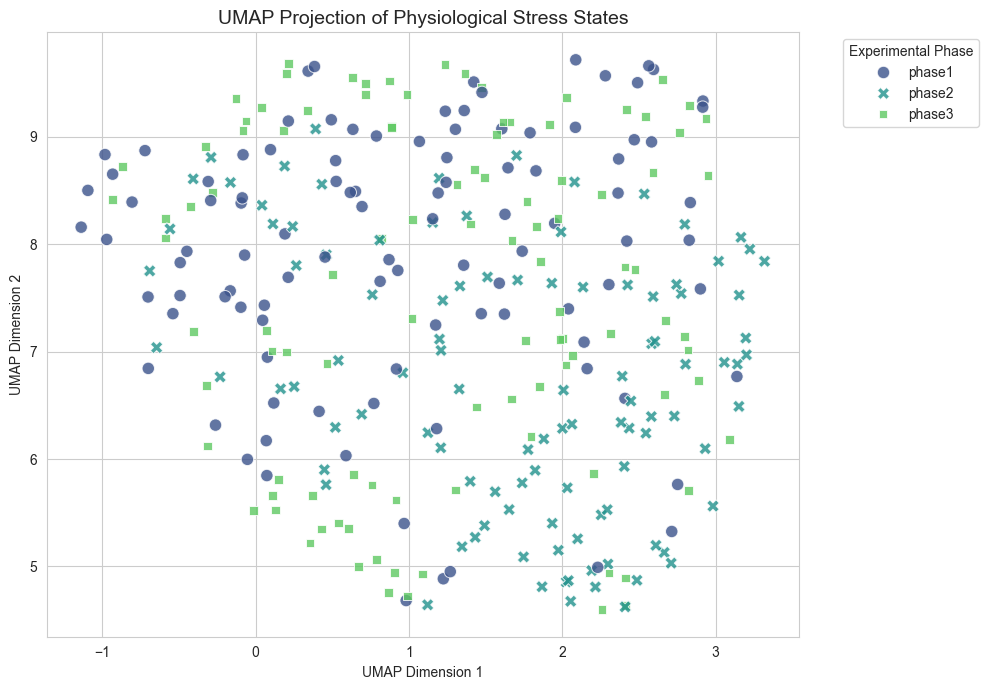

In [ ]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# read files
df_raw = pd.read_csv("df_preprocessed_nonlinear.csv", index_col=0)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if "Phase" in numeric_cols: # 預防萬一 Phase 被誤判為數字
    numeric_cols.remove("Phase")
if "Individual" in numeric_cols: # 預防萬一 Individual 被誤判為數字
    numeric_cols.remove("Individual")

# print(numeric_cols)

df_num = df_raw[numeric_cols].copy()
labels = df_raw["Phase"].values

# Umap implementation
reducer = umap.UMAP(
    n_neighbors=30, # local or global
    min_dist=0.1, # dense or sparse
    n_components=2, 
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(df_num)

df_viz = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
df_viz['Phase'] = labels # 直接補回標籤

# 5. Visulaizaito 
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    data=df_viz, 
    x='UMAP1', y='UMAP2', 
    hue='Phase', 
    style='Phase',
    palette='viridis', 
    s=80, alpha=0.8,
    edgecolor='w'
)

plt.title('UMAP Projection of Physiological Stress States', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Experimental Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

c:\Users\cwycw\miniconda3\envs\dtu02451\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Randomly selected Individual: 1


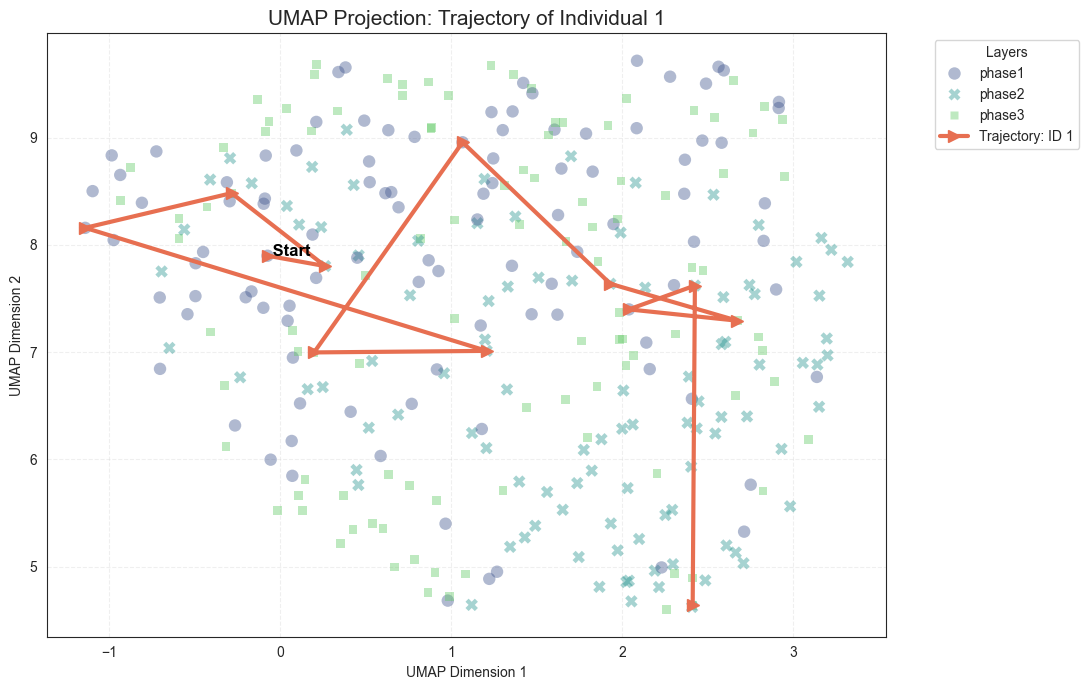

In [ ]:
### This section is to draw the line of individuals 
### So it will be messy
### Skip this if you think it's too messyy

import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# read files
df_raw = pd.read_csv("df_preprocessed_nonlinear.csv", index_col=0)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if "Phase" in numeric_cols: # 預防萬一 Phase 被誤判為數字
    numeric_cols.remove("Phase")
if "Individual" in numeric_cols: # 預防萬一 Individual 被誤判為數字
    numeric_cols.remove("Individual")

# print(numeric_cols)

df_num = df_raw[numeric_cols].copy()
labels = df_raw["Phase"].values

# Umap implementation
reducer = umap.UMAP(
    n_neighbors=30, # local or global
    min_dist=0.1, # dense or sparse
    n_components=2, 
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(df_num)

df_raw['UMAP1'] = embedding[:, 0]
df_raw['UMAP2'] = embedding[:, 1]

df_viz = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
df_viz['Phase'] = labels # 直接補回標籤

import random

# 5. Visualization 視覺化
plt.figure(figsize=(11, 7))
sns.set_style("white") # 建議換成 white 比較乾淨，方便看線

# --- [關鍵修改 1：隨機選取一個受試者] ---
all_individuals = df_raw['Individual'].unique()
random_ind = np.random.choice(all_individuals) # 隨機選一個
print(f"Randomly selected Individual: {random_ind}")

# --- [關鍵修改 2：畫出所有點作為背景] ---
sns.scatterplot(
    data=df_raw, 
    x='UMAP1', y='UMAP2', 
    hue='Phase', 
    style='Phase',
    palette='viridis', 
    s=80, alpha=0.4, # 降低背景點的透明度，讓線更明顯
    edgecolor='none',
    zorder=2
)

# --- [關鍵修改 3：針對選中的受試者畫出明顯的線] ---
# 取得該受試者的資料並按時間排序
subset = df_raw[df_raw['Individual'] == random_ind].sort_values('Time_Index')

# 畫線：使用鮮豔的顏色（如紅色或亮橘色）並增加寬度
plt.plot(
    subset['UMAP1'], subset['UMAP2'], 
    color='#e76f51',  # 鮮豔的珊瑚橘
    alpha=1.0, 
    linewidth=3,      # 加粗線條
    label=f'Trajectory: ID {random_ind}',
    marker='>',       # 在線條上加上小箭頭顯示方向
    markersize=8,
    zorder=3          # 確保線在最上層
)

# 在該軌跡的起點標註 "Start"
plt.text(
    subset['UMAP1'].iloc[0], subset['UMAP2'].iloc[0], 
    ' Start', fontsize=12, fontweight='bold', color='black'
)

plt.title(f'UMAP Projection: Trajectory of Individual {random_ind}', fontsize=15)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

# 調整圖例，確保軌跡標籤也被顯示
plt.legend(title='Layers', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

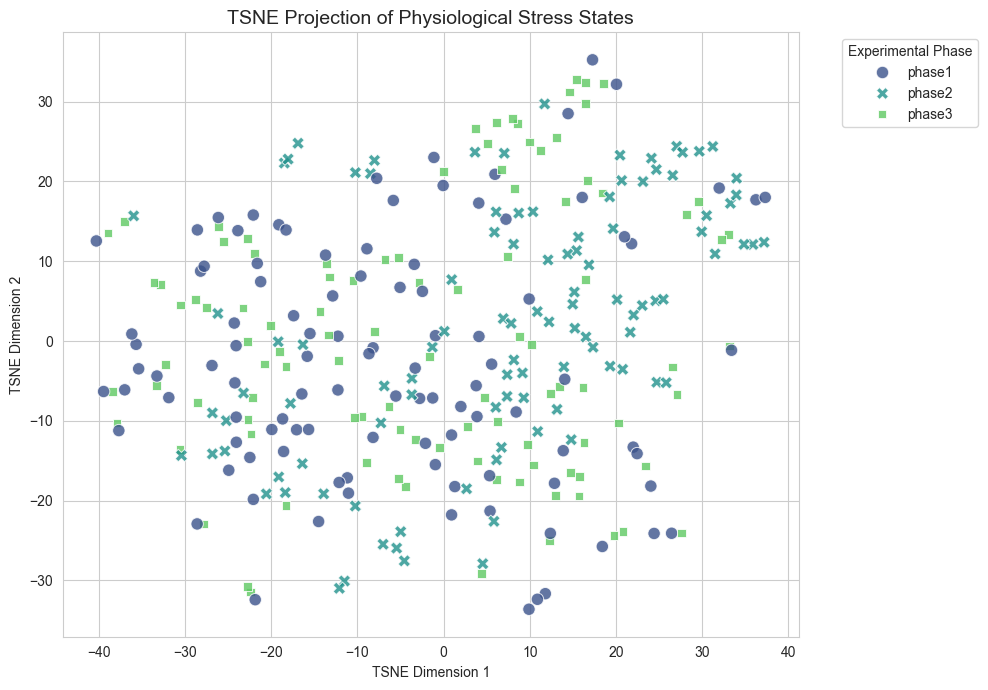

In [5]:
import pandas as pd
from sklearn.manifold import TSNE  
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_raw = pd.read_csv("df_preprocessed_nonlinear.csv", index_col=0)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

for col in ["Phase", "Individual", "Round", "Team_ID", "Cohort", "Time_Index"]:
    if col in numeric_cols:
        numeric_cols.remove(col)

df_num = df_raw[numeric_cols].copy()
labels = df_raw["Phase"].values


tsne = TSNE(
    n_components=2,
    perplexity=10, # similar to umap's n_neightbors
    learning_rate='auto',
    init='pca',      # use PCA highest variation point as the starting point
                     # to make it more stable
    random_state=42
)
embedding = tsne.fit_transform(df_num)

# 將結果存回 dataframe
df_viz = pd.DataFrame(embedding, columns=['TSNE1', 'TSNE2'])
df_viz['Phase'] = labels # 直接補回標籤

# 5. Visulaizaito 
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    data=df_viz, 
    x='TSNE1', y='TSNE2', 
    hue='Phase', 
    style='Phase',
    palette='viridis', 
    s=80, alpha=0.8,
    edgecolor='w'
)

plt.title('TSNE Projection of Physiological Stress States', fontsize=14)
plt.xlabel('TSNE Dimension 1')
plt.ylabel('TSNE Dimension 2')
plt.legend(title='Experimental Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Randomly selected Individual for t-SNE: 24


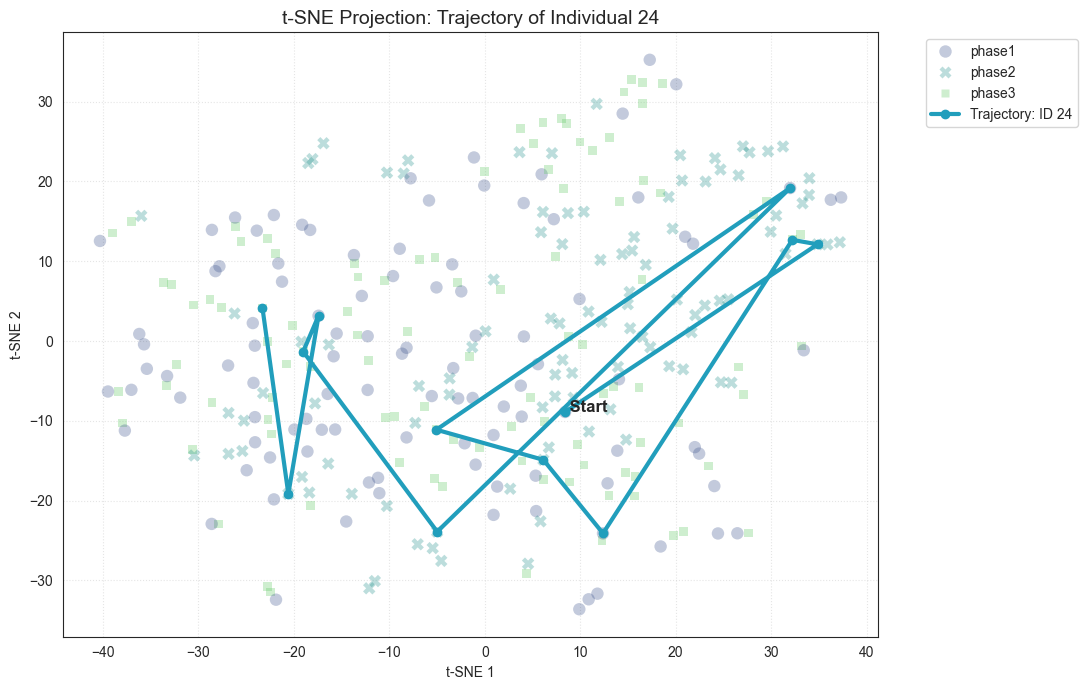

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE  
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_raw = pd.read_csv("df_preprocessed_nonlinear.csv", index_col=0)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

for col in ["Phase", "Individual", "Round", "Team_ID", "Cohort", "Time_Index"]:
    if col in numeric_cols:
        numeric_cols.remove(col)

df_num = df_raw[numeric_cols].copy()
labels = df_raw["Phase"].values


tsne = TSNE(
    n_components=2,
    perplexity=10, # similar to umap's n_neightbors
    learning_rate='auto',
    init='pca',      # use PCA highest variation point as the starting point
                     # to make it more stable
    random_state=42
)
embedding = tsne.fit_transform(df_num)

# 將結果存回 dataframe
df_raw['TSNE1'] = embedding[:, 0]
df_raw['TSNE2'] = embedding[:, 1]

# 3. 視覺化設置
plt.figure(figsize=(11, 7))
sns.set_style("white")

# Randomly choose one individual to plot the trajectory
all_individuals = df_raw['Individual'].unique()
random_ind = np.random.choice(all_individuals)
print(f"Randomly selected Individual for t-SNE: {random_ind}")

# 背景：所有點
sns.scatterplot(
    data=df_raw, 
    x='TSNE1', y='TSNE2', 
    hue='Phase', 
    style='Phase',
    palette='viridis', 
    s=80, alpha=0.3,
    edgecolor='none',
    zorder=1
)

# 前景：特定受試者的軌跡
subset = df_raw[df_raw['Individual'] == random_ind].sort_values('Time_Index')
plt.plot(
    subset['TSNE1'], subset['TSNE2'], 
    color='#219ebc',  # 換個亮藍色
    alpha=1.0, 
    linewidth=3, 
    marker='o',
    markersize=6,
    label=f'Trajectory: ID {random_ind}',
    zorder=2
)

# 標註起點
plt.text(
    subset['TSNE1'].iloc[0], subset['TSNE2'].iloc[0], 
    ' Start', fontsize=12, fontweight='bold'
)

plt.title(f't-SNE Projection: Trajectory of Individual {random_ind}', fontsize=14)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()